# Beta Bank Analisys Modeling

## Import libraries And Data Cleaning

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier
from sklearn.utils import shuffle
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt


In [ ]:
betabank = pd.read_csv("/data/Churn.csv")

print(betabank)

betabank.info()

# Fill missing values in Tenure
betabank["Tenure"] = betabank["Tenure"].fillna(betabank["Tenure"].median())

# Remove columns that should not be used as predictive features
betabank = betabank.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# Convert categorical variables into numerical variables
betabank = pd.get_dummies(
    betabank,
    columns=["Geography", "Gender"],
    drop_first=True
)

      RowNumber  CustomerId    Surname  CreditScore Geography  Gender  Age  \
0             1    15634602   Hargrave          619    France  Female   42   
1             2    15647311       Hill          608     Spain  Female   41   
2             3    15619304       Onio          502    France  Female   42   
3             4    15701354       Boni          699    France  Female   39   
4             5    15737888   Mitchell          850     Spain  Female   43   
...         ...         ...        ...          ...       ...     ...  ...   
9995       9996    15606229   Obijiaku          771    France    Male   39   
9996       9997    15569892  Johnstone          516    France    Male   35   
9997       9998    15584532        Liu          709    France  Female   36   
9998       9999    15682355  Sabbatini          772   Germany    Male   42   
9999      10000    15628319     Walker          792    France  Female   28   

      Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMemb

After studing the dataset we had some empty cells wihtin the Tenure colum that we filled out with the mean.
We deleted the "RowNumber", "CustomerId", "Surname" since these are columns that will not impact the model predictions about the clients terminating or keeping their contracts with Beta Bank.
Then we turned the "Gender" & "Geography" into numerical variables since the are categoricall features, this so we can properly use them into our prediction models.

## Data Spliting And Model Training

### Data Spliting

In [3]:
# Split the data
betabank_train, betabank_test = train_test_split(
    betabank,
    test_size=0.25,
    random_state=12345
)

betabank_test, betabank_valid = train_test_split(
    betabank_test,
    test_size=0.25,
    random_state=12345
)

# Separate features and target
train_features = betabank_train.drop(["Exited"], axis=1)
train_target = betabank_train["Exited"]

valid_features = betabank_valid.drop(["Exited"], axis=1)
valid_target = betabank_valid["Exited"]

#Examine class balance
print("Class balance")
print(train_target.value_counts()) 

Class balance
0    5998
1    1502
Name: Exited, dtype: int64


Here we separated all the data set for target trianing validation and testing, and review the Class balancing to understand where are we standing on how many clients churned or not.
Based on the value count of each class we can tell that there is aproximately 60% diference in which most clients are staying with Beta Bank, this bias can make the model predict that naturaly the client just wont leave and give us a no real prediciton of why or what is or can make the clients end contract with the company.

### Model Training Tree And Forest Unbalanced

In [4]:

# Decision Tree
best_score = 0
best_tree_par = None
best_precision = 0
best_recall = 0

for depth in range(1, 11):

    tree_model = DecisionTreeClassifier(
        random_state=54321,
        max_depth=depth
    )

    tree_model.fit(train_features, train_target)

    train_predictions = tree_model.predict(train_features)
    valid_predictions = tree_model.predict(valid_features)

    score = accuracy_score(valid_target, valid_predictions)

    if score > best_score:
        best_score = score
        best_tree_par = tree_model

#We messure the precision of the model
        best_precision = precision_score(valid_target, valid_predictions)
        best_recall = recall_score(valid_target, valid_predictions)


print(best_tree_par)
print("Best Decision Tree validation accuracy:", best_score)
print("Precision score of the model", best_precision)
print("Recall score of the model", best_recall)
print("F1 score of the model", f1_score(valid_target, valid_predictions))
print()

# Random Forest
forest_best_score = 0
best_forest_par = None
best_precision = 0
best_recall = 0

for est in range(1, 151):

    forest_model = RandomForestClassifier(
        random_state=54321,
        n_estimators=est,
        max_depth=7
    )

    forest_model.fit(train_features, train_target)

    train_predictions = forest_model.predict(train_features)
    valid_predictions = forest_model.predict(valid_features)

    score = accuracy_score(valid_target, valid_predictions)

    if score > forest_best_score:
        forest_best_score = score
        best_forest_par = forest_model
#We messure the precision of the model
        best_precision = precision_score(valid_target, valid_predictions)
        best_recall = recall_score(valid_target, valid_predictions)

print(best_forest_par)
print("Best Random Forest validation accuracy:", forest_best_score)
print("Precision score of the model", best_precision)
print("Recall score of the model", best_recall)
print("F1 score of the model", f1_score(valid_target, valid_predictions))


DecisionTreeClassifier(max_depth=6, random_state=54321)
Best Decision Tree validation accuracy: 0.8704
Precision score of the model 0.8309859154929577
Recall score of the model 0.4609375
F1 score of the model 0.5462555066079295



/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


RandomForestClassifier(max_depth=7, n_estimators=37, random_state=54321)
Best Random Forest validation accuracy: 0.8768
Precision score of the model 0.8805970149253731
Recall score of the model 0.4609375
F1 score of the model 0.5608465608465609



The data has a significant class imbalance: approximately 80% of customers stayed (class 0) while only 20% left (class 1). Because of this imbalance, the models tend to favor the majority class, which explains why they achieved high accuracy but relatively low recall.

The Decision Tree achieved 87.04% accuracy, 83.10% precision, 46.09% recall, and an F1 of 0.5463. The Random Forest performed slightly better with 87.68% accuracy, 88.06% precision, 46.09% recall, and an F1 of 0.5608. However, both models failed to reach the required F1 of 0.59 and identified less than half of the customers who actually left.

The UndefinedMetricWarning is not necessarily a coding error; it indicates that at some point the model predicted no positive samples, making precision undefined. Overall, these results show that accuracy alone is not sufficient for this problem. We need to correct the class imbalance using techniques such as class_weight="balanced" and oversampling, then evaluate the models primarily using F1, recall, and AUC-ROC.

### Upsampling Blancing

In [5]:
#Separate the data

features_zeros = train_features[train_target == 0]
features_ones = train_features[train_target == 1]
target_zeros = train_target[train_target == 0]
target_ones = train_target[train_target == 1]

#Create the upsample

repeat = int(round(len(target_zeros)/len(target_ones)))

features_upsampled = pd.concat(
    [features_zeros] + [features_ones] * repeat)

target_upsampled = pd.concat(
    [target_zeros] + [target_ones] * repeat)

features_upsampled, target_upsampled = shuffle(
    features_upsampled, target_upsampled, random_state=12345)

#Examine class balance

print("Class balance")
print(target_upsampled.value_counts()) 



Class balance
1    6008
0    5998
Name: Exited, dtype: int64


Now after doing an upsampling we have a balance dataset on which the model can work with the class 1 since is now on a 50/50 distribution.

### Model Trining Balanced

In [6]:
# Decision Tree

# Score Storage Variables
best_score = 0
best_tree_par = None
best_precision = 0
best_recall = 0

# We set the depth tree and train the model

for depth in range(1, 11):

    tree_model = DecisionTreeClassifier(
        random_state=54321,
        max_depth=depth
    )

    tree_model.fit(features_upsampled, target_upsampled)

#Run model predicitons

    train_predictions = tree_model.predict(train_features)
    valid_predictions = tree_model.predict(valid_features)

    score = accuracy_score(valid_target, valid_predictions)

    if score > best_score:
        best_score = score
        best_tree_par = tree_model

#We messure the precision of the model
        
        best_precision = precision_score(valid_target, valid_predictions)
        best_recall = recall_score(valid_target, valid_predictions)


print(best_tree_par)
print("Best Decision Tree validation accuracy:", best_score)
print("Precision score of the model:", best_precision)
print("Recall score of the model:", best_recall)
print("F1 score of the model:", f1_score(valid_target, valid_predictions))
print()

# Random Forest

#Score Storage Variables

forest_best_score = 0
best_forest_par = None
best_precision = 0
best_recall = 0

# We set the depth and training of the model

for est in range(1, 151):

    forest_model = RandomForestClassifier(
        random_state=54321,
        n_estimators=est,
        max_depth=7
    )

    forest_model.fit(features_upsampled, target_upsampled)
    
# Run the model predictions
    
    train_predictions = forest_model.predict(train_features)
    valid_predictions = forest_model.predict(valid_features)

    score = accuracy_score(valid_target, valid_predictions)

    if score > forest_best_score:
        forest_best_score = score
        best_forest_par = forest_model
        
#We messure the precision of the model
        
        best_precision = precision_score(valid_target, valid_predictions)
        best_recall = recall_score(valid_target, valid_predictions)

print(best_forest_par)
print("Best Random Forest validation accuracy:", forest_best_score)
print("Precision score of the model:", best_precision)
print("Recall score of the model:", best_recall)
print("F1 score of the model:", f1_score(valid_target, valid_predictions))
print()


#Logistic Regression


log_model = LogisticRegression(random_state=54321, solver='liblinear')
log_model.fit(features_upsampled, target_upsampled)

log_score_train = log_model.score(train_features, train_target)
log_score_valid = log_model.score(valid_features, valid_target)

log_predictions = log_model.predict(valid_features)

print(log_model)
print("Logistic Model validation accuracy:", log_score_valid)
print("Precision score of the model:", precision_score(valid_target, log_predictions))
print("Recall score of the model:", recall_score(valid_target, log_predictions))
print("F1 score of the model:", f1_score(valid_target, log_predictions))

DecisionTreeClassifier(max_depth=5, random_state=54321)
Best Decision Tree validation accuracy: 0.8176
Precision score of the model: 0.5421686746987951
Recall score of the model: 0.703125
F1 score of the model: 0.5846153846153846

RandomForestClassifier(max_depth=7, n_estimators=69, random_state=54321)
Best Random Forest validation accuracy: 0.8368
Precision score of the model: 0.5738636363636364
Recall score of the model: 0.7890625
F1 score of the model: 0.6491803278688525

LogisticRegression(random_state=54321, solver='liblinear')
Logistic Model validation accuracy: 0.6432
Precision score of the model: 0.3151750972762646
Recall score of the model: 0.6328125
F1 score of the model: 0.42077922077922075


The upsampling technique improved the models' ability to identify customers from the minority class. 

The Random Forest performed the best, achieving 83.68% accuracy, 57.39% precision, 78.91% recall, and an F1 score of 0.649. This exceeds the required F1 score of 0.59. 

Its high recall is particularly valuable because the goal is to identify as many customers at risk of leaving as possible. The Decision Tree reached an F1 of 0.585, slightly below the required threshold, while Logistic Regression performed considerably worse with an F1 of 0.421. 

Therefore, based on the validation results, Random Forest with upsampled data is the strongest model so far.

### Downsample Balancing

In [7]:
#Downsample Balancing

fraction = len(target_ones)/len(target_zeros)

features_downsampled = pd.concat(
        [features_zeros.sample(frac=fraction, random_state=12345)] + [features_ones])

target_downsampled = pd.concat(
        [target_zeros.sample(frac=fraction, random_state=12345)] + [target_ones])

features_downsampled, target_downsampled = shuffle(
        features_downsampled, target_downsampled, random_state=12345)

print("Class balance")
print(target_downsampled.value_counts())

Class balance
0    1502
1    1502
Name: Exited, dtype: int64


Here we try using downsampling to compare if the models behave coherently with a higger as with lower sample amount of data

### Model Training

In [ ]:
# Random Forest
forest_best_score = 0
best_forest_down = None
best_precision = 0
best_recall = 0

for est in range(1, 151):

    forest_model = RandomForestClassifier(
        random_state=54321,
        n_estimators=est,
        max_depth=7
    )

    forest_model.fit(features_downsampled, target_downsampled)

    train_predictions = forest_model.predict(train_features)
    valid_predictions = forest_model.predict(valid_features)

    score = accuracy_score(valid_target, valid_predictions)

    if score > forest_best_down:
        forest_best_down = score
        best_forest_par = forest_model
#We messure the precision of the model
        best_precision = precision_score(valid_target, valid_predictions)
        best_recall = recall_score(valid_target, valid_predictions)

print(best_forest_down)
print("Best Random Forest validation accuracy:", forest_best_sc)
print("Precision score of the model", best_precision)
print("Recall score of the model", best_recall)
print("F1 score of the model", f1_score(valid_target, valid_predictions))
print()

#Logistic Regression

log_model = LogisticRegression(random_state=54321, solver='liblinear')
log_model.fit(features_downsampled, target_downsampled)

log_score_train = log_model.score(train_features, train_target)
log_score_valid = log_model.score(valid_features, valid_target)

log_predictions = log_model.predict(valid_features)

print(log_model)
print("Logistic Model validation accuracy:", log_score_valid)
print("Precision score of the model:", precision_score(valid_target, log_predictions))
print("Recall score of the model:", recall_score(valid_target, log_predictions))
print("F1 score of the model:", f1_score(valid_target, log_predictions))

RandomForestClassifier(max_depth=7, n_estimators=5, random_state=54321)
Best Random Forest validation accuracy: 0.8112
Precision score of the model 0.5277777777777778
Recall score of the model 0.7421875
F1 score of the model 0.6196319018404908

LogisticRegression(random_state=54321, solver='liblinear')
Logistic Model validation accuracy: 0.6528
Precision score of the model: 0.3241106719367589
Recall score of the model: 0.640625
F1 score of the model: 0.4304461942257218


With downsampling, we can see a slight difference in the models’ results compared to the previous experiments. However, the results remain consistent overall, indicating that the models are producing coherent and reliable predictions. These results further support the decision to use the Random Forest model trained with upsampling, as it provides the best overall performance while maintaining consistent results across different sampling approaches.

## Best Model Testing (Random Forest)

### Data preparation and Model Testing

In [9]:


#We separate the features and target

test_features = betabank_test.drop(["Exited"], axis=1)
test_target = betabank_test["Exited"]

#Call the trained model and run predictions

test_predictions = best_forest_par.predict(test_features)

#Run the scores functions

test_score_accuracy = accuracy_score(test_target,test_predictions)

print("Accuracy score of final trained model:",test_score_accuracy)
print("Precision score of the model:", precision_score(test_target, test_predictions))
print("Recall score of the model:", recall_score(test_target, test_predictions))
print("F1 score of the model:", f1_score(test_target, test_predictions))



Accuracy score of final trained model: 0.8005333333333333
Precision score of the model: 0.5302752293577981
Recall score of the model: 0.7100737100737101
F1 score of the model: 0.6071428571428572


The final Random Forest model achieved an accuracy of 80.05% on the test set, demonstrating good overall predictive performance. The model also achieved a recall of 71.01%, meaning it was able to correctly identify most customers who actually left the bank. Although the precision score of 53.03% indicates that some customers predicted to churn did not actually leave, the F1 score of 60.71% shows a reasonable balance between precision and recall. Overall, these results confirm that the Random Forest model is suitable for predicting customer churn and provides a solid basis for identifying customers who may be at risk of leaving.

### Precision vs Recall Comparison

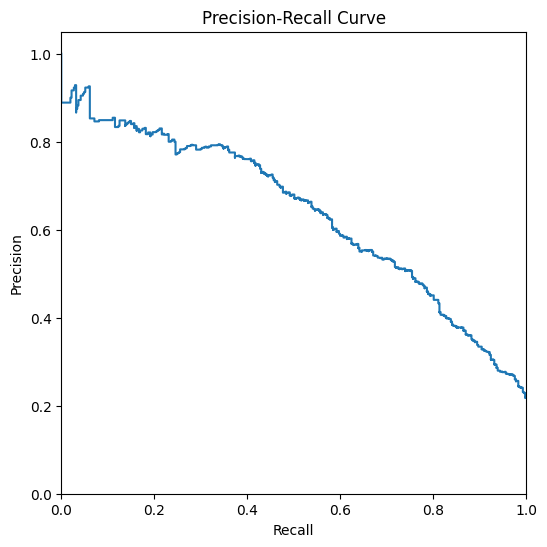

In [10]:
probabilities = best_forest_par.predict_proba(test_features)

probabilities_one = probabilities[:,1]

precision, recall, thresholds = precision_recall_curve(
    test_target, probabilities_one
)
plt.figure(figsize=(6, 6))
plt.step(recall, precision, where='post')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve')
plt.show()

### AUC - ROC Analysis

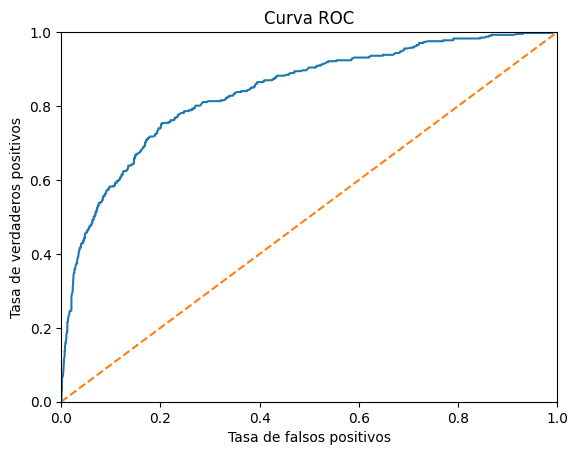

AUC - ROC Score: 0.8385533477495329
Threshold = 0.60 | Precision = 0.606, Recall = 0.582


In [11]:
# Set parameters and calculate curve

fpr, tpr, thresholds = roc_curve(test_target, probabilities_one)

#Graph for vizualisation

plt.figure()

plt.plot(fpr,tpr)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.show()

# AUC - ROC Variable

auc_roc = roc_auc_score(test_target,probabilities_one)

print("AUC - ROC Score:", auc_roc)

# Test to compare F1 score with roc curve threshold


best_threshold = float("inf")
threshold_score = None

for threshold in np.arange(0.4, 0.8, 0.04):
    predicted_valid = probabilities_one > threshold
    precision = precision_score(test_target,predicted_valid)
    recall = recall_score(test_target,predicted_valid)

    dif = abs(precision - recall)
    
    if best_threshold > dif:

        best_threshold = dif
        threshold_score = threshold, precision, recall
print(
            'Threshold = {:.2f} | Precision = {:.3f}, Recall = {:.3f}'.format(
                threshold_score[0] , threshold_score[1] , threshold_score[2] ,
            )
        )



The probability and threshold analysis provides a deeper evaluation of the Random Forest model. The model achieved a ROC-AUC score of 0.838, indicating that it has a good ability to distinguish between customers who are likely to leave the bank and those who are likely to stay. The threshold analysis also shows a clear trade-off between precision and recall: lowering the threshold increases recall but also produces more false positives, while increasing the threshold improves precision at the cost of identifying fewer customers who are likely to leave. For example, at the default threshold of 0.50, the model provides a reasonable balance between both metrics, while a lower threshold such as 0.40 could be considered if the main objective is to identify as many potential churners as possible. Overall, these results confirm that the Random Forest model is effective for customer churn prediction, and the optimal threshold can be adjusted depending on the business objective.

## Conclusion

We develop a machine learning model capable of predicting which customers are most likely to leave Beta Bank. After testing different approaches, including Decision Tree and Random Forest models, as well as addressing the class imbalance through upsampling and downsampling, the Random Forest model trained with upsampled data provided the best and most consistent overall performance.

On the test set, the final model achieved an accuracy of 80.05%, a recall of 71.01%, a precision of 53.03%, and an F1 score of 60.71%. The ROC-AUC score of 0.839 further demonstrates that the model has a good ability to distinguish between customers who are likely to leave and those who are likely to stay. The threshold analysis also showed that the model's precision and recall can be adjusted depending on the business objective. A lower threshold can help identify more potential customers at risk of leaving, while a higher threshold can reduce false positives.

Overall, the results demonstrate that the Random Forest model is a suitable solution for predicting customer churn. By identifying customers with a higher probability of leaving, Beta Bank could use these predictions to develop targeted retention strategies and focus its resources on customers who are most likely to churn. This makes the model not only statistically effective but also potentially valuable from a business perspective.
